# DATA 501 — Weekly Assignment 4
## Exploring & Interpreting Data: Answering the Manager

**Name:** *Zaharia Selman*

**NetID:** *zselman*

---

### Scenario
Week four at **Ride Knox**. Your manager saw the wrangling report and replied:
*"Great, the data's clean — so IS ridership down or not? And where do the new
stations go? I have a leadership meeting Friday. One page, with charts."*

This is the payoff week. Everything from Weeks 1–3 was preparation for this:
turning 247,967 clean rows into an honest answer a non-technical manager can
act on.

One new piece of information from the scenario: **Ride Knox raised casual
single-ride prices on July 1, 2025.** Keep that in your back pocket.

### Setup
- Download `trips_2025.csv` and `stations.xlsx` from Canvas (same files as
  Weeks 2–3).
- Put them **in the same folder as this notebook**.

### Instructions
- Complete every cell marked **`# TODO`**.
- Answer every **Q:** prompt in the markdown cells — a chart without an
  interpretation is just decoration.
- **Every chart needs a title, axis labels, and (where relevant) a legend.**
  Unlabeled charts lose points no matter how correct the code is.
- Heads-up: the tasks below use the **same tools** as the class notebook but
  on **different slices, columns, and settings**. Code pasted straight from
  the class demo will run on the wrong data or give the wrong numbers — read
  each prompt.
- Run each cell as you go (**Shift+Enter**).
- Before submitting: **Kernel → Restart & Run All**. Your notebook must
  rebuild everything from the raw files, top to bottom, with no errors.
- Submit the `.ipynb` file on Canvas.

### Grading (100 points)
| Part | Points |
|---|---|
| 0. Rebuild the clean dataset (provided pipeline) | 5 |
| 1. Center & skew | 10 |
| 2. Spread & percentiles | 5 |
| 3. Categorical summaries | 5 |
| 4. Group comparisons | 10 |
| 5. EDA: the ridership question (tables) | 10 |
| 6. Chart 1 — typical trip length by month (line) | 5 |
| 7. Chart 2 — the money chart (member vs. casual) | 15 |
| 8. Chart 3 — trip durations (histogram) | 10 |
| 9. Chart 4 — station pressure (bar) | 10 |
| 10. The findings memo | 10 |
| Reflection + AI disclosure | 5 |
<!-- | Notebook runs top-to-bottom, all charts labeled | *(required — up to −10 if not)* | -->
| 11. Challenge (optional) | *+5 extra credit* |


---
## Part 0 — Rebuild the Clean Dataset (5 pts)

Week 3's cleaning, condensed into one provided pipeline. **Run these two
cells without modifying them.** (If your Assignment 3 pipeline differed in a
documented, defensible way, you may substitute it — but your final row count
should be close to **247,967**.)

Why we give you this: this week is graded on *analysis and communication*,
not on re-doing the cleaning. But notice what you're running — this is what a
reusable pipeline looks like.

**0a.** Run the pipeline cell. **0b.** Print the shape of `trips` and of
`merged` to confirm the starting line.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Week 3 cleaning pipeline (run as-is) ---
trips = pd.read_csv("trips_2025.csv")
stations = pd.read_excel("stations.xlsx")

trips = trips.drop_duplicates()                                    # 600 duplicate rows
trips = trips[trips["start_station_id"] != "S99"]                  # test station

trips["rider_type"] = trips["rider_type"].str.strip().str.lower()  # 6 spellings -> 2
trips["start_station_name"] = (
    trips["start_station_name"].str.strip().str.title()
)

trips["no_end"] = trips["end_station_id"].isna()                   # keep + flag

trips["start_time"] = pd.to_datetime(trips["start_time"])
trips["end_time"]   = pd.to_datetime(trips["end_time"])
trips["duration_min"] = (
    (trips["end_time"] - trips["start_time"]).dt.total_seconds() / 60
)
trips = trips[(trips["duration_min"] >= 1) & (trips["duration_min"] <= 24 * 60)]

trips["month"]      = trips["start_time"].dt.month
trips["hour"]       = trips["start_time"].dt.hour
trips["day_name"]   = trips["start_time"].dt.day_name()
trips["is_weekend"] = trips["day_name"].isin(["Saturday", "Sunday"])


In [2]:
# --- The Week 3 merge (run as-is) ---
merged = pd.merge(
    trips, stations,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged) == len(trips)   # trust, but verify

# TODO 0b: print the shape of trips and of merged
trips.shape
merged.shape

(247967, 21)

---
## Part 1 — Center & Skew (10 pts)

In class we summarized `duration_min` for **all** trips. The fleet team has a
narrower question: they only maintain the **classic** bikes and want the same
summary for their share of the fleet.

**1a.** Filter to trips where `bike_type` is `"classic"` (Week 3's boolean
filtering, now feeding Week 4's statistics), then compute the **mean**,
**median**, and **mode** of `duration_min` for that subset.

**1b.** Within the classic-bike subset, compute the mean and the median
again, but only for trips longer than **45 minutes** — just to see how a
subset shifts the summaries.

**Q1c:** Compare the mean and median from 1a. Which is larger, what does
that tell you about the *shape* of the duration distribution, and which one
would you report to the fleet team as "the typical classic-bike trip"? Why?

**Q1d:** A teammate says: *"Just report the mean — it uses all the data, so
it's more accurate."* In 1–2 sentences, what's wrong with this argument for
this column?


In [3]:
# TODO 1a: filter to classic bikes; mean, median, mode of duration_min
classic_bikes = merged[merged["bike_type"] == 'classic']
# print(classic_bikes)

print(classic_bikes["duration_min"].mean())
print(classic_bikes["duration_min"].median())
print(classic_bikes["duration_min"].mode())
# print(classic_bikes.dtypes)

# TODO 1b: mean and median for classic-bike trips longer than 45 minutes
print(classic_bikes[classic_bikes["duration_min"] > 45]["duration_min"].mean())
print(classic_bikes[classic_bikes["duration_min"] > 45]["duration_min"].median())

16.892283201578884
13.716666666666667
0    9.166667
Name: duration_min, dtype: float64
60.3492810854597
54.80833333333334


**Q1c:** *Between the mean and median duration trip for the classic bikes, the mean is larger. This tells me that the distribution of this variable for this particular type of bike is positively skewed (there are long duration trips pulling the average to be larger than the typical duration). Therefore, I would report the median as "the typical classic-bike trip" to the fleet team to account for this variation from the duration that most trips with the classic bike actually show.*

**Q1d:** *This argument is wrong for the duration column, because even though the mean includes all the data this means that it also includes outliers that will skew the genuine result that we are looking for. If this were a normal distribution, the mean would be great to use, because the mean, median, and mode would all be the same value.*

---
## Part 2 — Spread & Percentiles (5 pts)

In class we looked at the quartiles of all trips. The membership team wants
the picture for **their** riders — and they care about the edges, not the
middle.

**2a.** Filter to **member** trips and run `.describe()` on their
`duration_min`.

**2b.** For the same member subset, compute the **10th and 90th
percentiles** of `duration_min` with a single `.quantile()` call — the range
that covers the middle 80% of member trips.

**Q2c:** A member trip lasts **5 minutes**. Using your percentiles, is that
unusually short for a member? Justify with a number, not a gut feeling.


In [4]:
# TODO 2a: describe() on duration_min for member trips only
merged[merged["rider_type"] == 'member']["duration_min"].describe

# TODO 2b: 10th and 90th percentiles for member trips (one .quantile() call)
merged[merged["rider_type"] == 'member']["duration_min"].quantile([.10, .90])

0.1     5.733333
0.9    23.516667
Name: duration_min, dtype: float64

**Q2c:** *According to our data, a 5 minute ride for a member is short, but not unusual. Most member riders last for at least 5.7 (~6 min) to about 24 minutes.*

---
## Part 3 — Categorical Summaries (5 pts)

**3a.** What **share** of trips use each `bike_type`? (Counts *and*
proportions.)

**3b.** In Week 3 you created the `no_end` flag instead of deleting those
rows. That decision pays off now: what share of trips have **no recorded end
station**? (Hint: `value_counts()` works on your flag column like on any
other.)

**Q3c:** Report the no-end-station share as a manager-ready sentence —
percentage **and** denominator (recall from class: a percentage without a
total is how people get fooled). Why might this number belong in Friday's
memo?


In [5]:
# TODO 3a: bike_type counts and shares
print(merged["bike_type"].value_counts()) # counts
print(merged["bike_type"].value_counts(normalize=True)*100) #proportions

# TODO 3b: share of trips with no recorded end station (the no_end flag)
print(f"\n{merged["no_end"].value_counts()}")
print(merged["no_end"].value_counts(normalize=True)*100)

bike_type
classic     153695
electric     94272
Name: count, dtype: int64
bike_type
classic     61.982038
electric    38.017962
Name: proportion, dtype: float64

no_end
False    244241
True       3726
Name: count, dtype: int64
no_end
False    98.497381
True      1.502619
Name: proportion, dtype: float64


**Q3c:** *About 2% of 247,967 trips do not have a reported end station in our dataset. This number belongs in Friday's memo because it affects how we are able to assess if ridership is down or not. If we don't have end stations for a set of stations, we cannot calculate durations, arrivals per dock per station, etc. for those entire trips.*

---
## Part 4 — Group Comparisons (10 pts)

In class we compared rider types. The fleet team wants the same treatment
for **bike types** — they suspect electric bikes get used for longer trips.

**4a.** Compute the **median** trip duration for each `bike_type`.

**4b.** Run `.describe()` on `duration_min` grouped by `bike_type`
(one line: `groupby` + `describe`).

**4c.** Now combine two tools from this week that we didn't combine in
class: compute the **90th percentile** of `duration_min` for each
`rider_type` (`groupby` + `.quantile(0.9)`). The median tells you about the
typical trip; the 90th percentile tells you about each group's *long* trips.

**Q4d:** Two findings to interpret honestly. First: what did 4a/4b show
about electric vs. classic durations — and if the answer is "essentially no
difference," what does that *rule out* as an explanation for anything else
we've found? Second: describe the rider-type gap in 4c with numbers, offer
*one plausible interpretation* (clearly labeled as interpretation), and *one
alternative explanation* the data can't rule out.


In [6]:
# TODO 4a: median duration by bike_type
print(merged.groupby("bike_type")["duration_min"].median())

# TODO 4b: grouped describe() by bike_type
print(f"\n{merged.groupby("bike_type")["duration_min"].describe()}")

# TODO 4c: 90th percentile of duration by rider_type
print(f"\n{merged.groupby("rider_type")["duration_min"].quantile([.90])}") #long trips taken by each rider type (casual and member)

bike_type
classic     13.716667
electric    13.750000
Name: duration_min, dtype: float64

              count       mean        std  min       25%        50%  \
bike_type                                                             
classic    153695.0  16.892283  12.011622  1.5  9.133333  13.716667   
electric    94272.0  16.950584  12.052152  1.5  9.133333  13.750000   

                 75%    max  
bike_type                    
classic    20.833333  180.0  
electric   21.000000  180.0  

rider_type     
casual      0.9    41.133333
member      0.9    23.516667
Name: duration_min, dtype: float64


**Q4d:** 
- *There is essentially no difference between electric vs. classic durations meaning that we can rule out that electric bikes get used for longer rides.*
- *There is a 17.6 min gap between the duration of casual vs member riders, where casual riders take longer trips than member riders do. **One plausible interpretation** for this could be the overall cheaper price of the casual package. Maybe they use it more often because of the perceived deal of having a lower price. On the other hand, casual riders may take longer, leasure trips than member riders going to work or school, but the data cannot prove or disprove this because we do not have data on *why* riders take trips using Ride Knox.*

---
## Part 5 — EDA: The Ridership Question (10 pts)

Time to answer question #1: *"Is ridership down?"*

**5a.** Build the month-by-rider-type trip counts as a table with **rider
types as the rows and months 1–12 as the columns**. (Careful: this is the
*transpose* of the class demo's table — think about the order of the columns
in your `groupby`. Code copied from class will come out sideways.)

**5b.** New combination: using arithmetic on your 5a table (the same kind of
column math you used for `trips_per_dock` in Week 3), compute the **casual
share of each month's trips**: casual ÷ (casual + member), month by month.

**5c.** Compute the **percent change** in trips from June to July for each
rider type, using your 5a table. (Mind your indexing — rider types are the
rows now.)

**Q5d:** Answer the manager in 3–4 sentences: Is ridership down? **For
whom, and since when?** What does the casual-share row in 5b add that the
raw counts don't? Mention the July 1 price change — carefully (what can you
claim, and what can't you?).


In [13]:
# TODO 5a: month-by-rider-type counts, rider types as ROWS, months as COLUMNS
merged.groupby(["rider_type", "month"]).size().unstack()

# TODO 5b: casual share of each month's trips (arithmetic on the 5a table)
share_cas = merged[merged["rider_type"] == 'casual'].groupby("month").size() / merged.groupby("month")['rider_type'].size()*100
# print(share_cas[7])

# TODO 5c: June -> July percent change for each rider type
perc_change_cas = share_cas[7] - share_cas[6]

share_mem = merged[merged["rider_type"] == 'member'].groupby("month").size() / merged.groupby("month")['rider_type'].size()*100
perc_change_mem = share_mem[7] - share_mem[6]

print(perc_change_cas)
print(perc_change_mem)

-10.418445950894103
10.41844595089411


**Q5d:** *Both rider types seem to have a natural progression then decline throughout the year. However, ridership does seem to be down for casual riders starting in July where the amount of casual riders drops significantly (10.4% out of 31,279 (June) - 26,926 (July) total riders) from June to July 2025. We can suspect that this decline in casual riders is from the price increase that occurred in July 2025. The casual share of each month's trips adds standardization so that we can compare growth/decline across months with varying total numbers of rider types.*

---
## Part 6 — Chart 1: Typical Trip Length by Month (Line) (5 pts)

In class we drew trips-per-month. Here's a different monthly question:
does the **typical trip length** change over the year?

**6a.** Compute the **median** `duration_min` for each month (`groupby` +
an aggregation — same move as the class demo, different statistic), then
draw a **line chart** of it. Title, axis labels, units.

**Q6b:** One sentence: what is the single point this chart makes? (Look
closely at the second half of the year.)


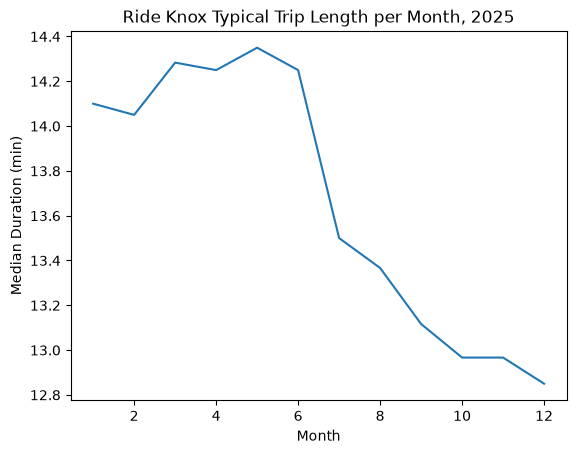

In [8]:
# TODO 6a: median duration per month, then a labeled line chart of it
typical_trips = merged.groupby("month")["duration_min"].median()

plt.plot(typical_trips.index, typical_trips.values)
plt.title("Ride Knox Typical Trip Length per Month, 2025")
plt.xlabel("Month")
plt.ylabel("Median Duration (min)")
plt.show()

**Q6b:** *Ride Knox riders typically take increasingly longer trips during the beginning of the year (when the weather is warming) and shorter trips starkly after June 2025 (possibly as the weather cools down towards the end of the year, amd/or due to the price increase in July 2025).*

---
## Part 7 — Chart 2: The Money Chart (15 pts)

This is the **one chart you rebuild exactly as in class** — deliberately.
It's the chart that goes to the leadership meeting, and you should be able
to produce it from memory. One catch: your table from 5a is oriented
differently than the class demo, so your *indexing* will need to adapt even
though the chart is the same.

**7a.** Plot **member and casual trips per month as two lines on one
chart**, with:
- a `label` for each line and a `legend`
- markers on the data points
- a dashed vertical line at month 7 marking the July 1 price change
- title and axis labels

**7b.** Save it with `plt.savefig("monthly_by_rider_type.png",
dpi=150, bbox_inches="tight")` — *before* `plt.show()`.

**Q7c:** The five-second test: write the one sentence a cold viewer should
take from this chart.

**Q7d:** Why is the dashed vertical line honest to include, and what
*caption text* would you put under this chart so it doesn't overclaim?
(1–2 sentences of caption, written out.)


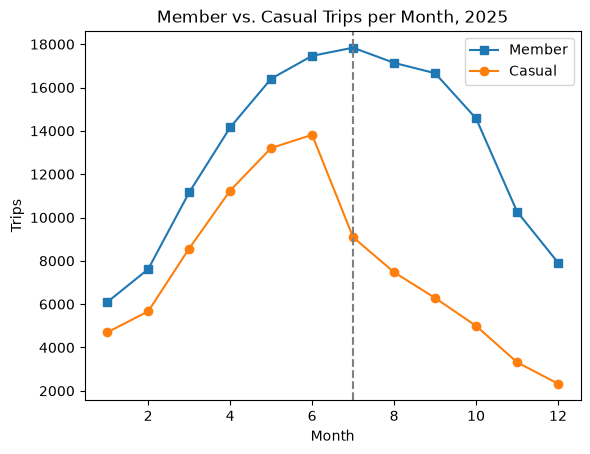

In [9]:
# TODO 7a: two-line chart with legend, markers, and axvline at month 7
#          (plot from your Part 5a table -- rider types are rows)
monthly = merged.groupby(["rider_type", "month"]).size().unstack()
plt.plot(monthly.columns, monthly.loc["member"], label="Member", marker="s") #Used AI here
plt.plot(monthly.columns, monthly.loc["casual"], label="Casual", marker="o")
plt.axvline(x=7, linestyle="--", color="gray") # July 1 price change
plt.title("Member vs. Casual Trips per Month, 2025")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()

# TODO 7b: savefig, then show
plt.savefig("monthly_by_rider_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Q7c:** *Number of trips taken by Member and Casual riders shows a cyclical pattern, however, casual riders starkly decline at a much faster rate than member riders after July 2025.*

**Q7d:** *The dashed vertical line is honest to include because it makes it clear where the major shift occurs in the data.*

- **Caption text:** *This figure represents the total number of member and casual riders that Ride Knox served from January - December 2025. There is a natural increase and decrease in riders throughout the year, however, this year shows a stark decrease in casual riders after June 2025.*

---
## Part 8 — Chart 3: Trip Durations (Histogram) (10 pts)

The fleet team again: they want the duration picture for **classic bikes
only** (your Part 1 subset).

**8a.** Draw a **histogram** of classic-bike `duration_min` with **40
bins**. Title and labels.

**8b.** Redraw it with **12 bins** and with **160 bins** (two more charts,
or side-by-side if you're feeling fancy).

**Q8c:** What feature of the distribution is visible at 40 bins? What did
12 bins hide, and what did 160 bins add (or was it just noise)? Connect what
you see to your Part 1 mean-vs-median answer.


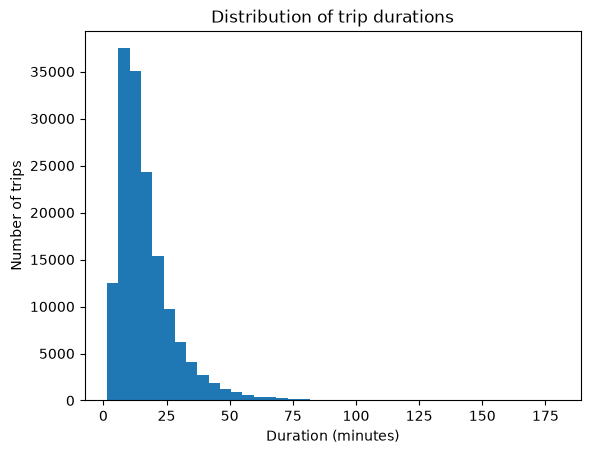

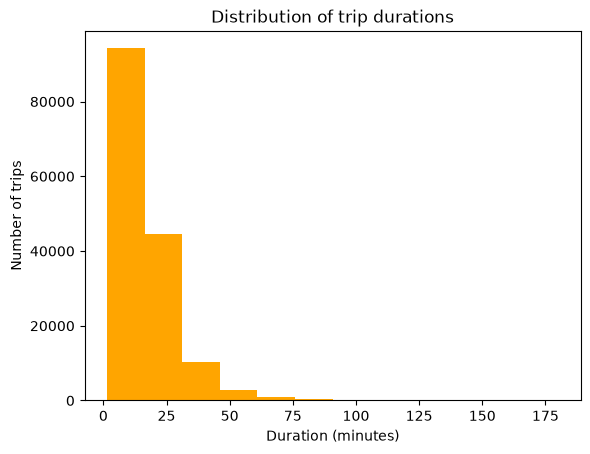

Text(0, 0.5, 'Number of trips')

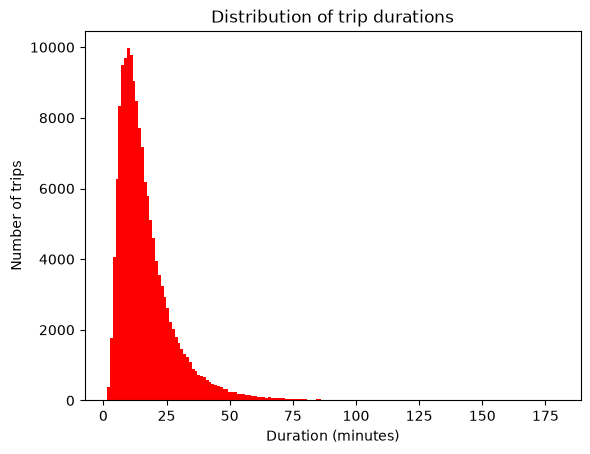

In [17]:
# TODO 8a: histogram of classic-bike durations, 40 bins
plt.hist(classic_bikes["duration_min"], bins=40)
plt.title("Distribution of trip durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.show()

# TODO 8b: same histogram with 12 bins and with 160 bins
plt.hist(classic_bikes["duration_min"], color='orange', bins=12)
plt.title("Distribution of trip durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.show()
plt.hist(classic_bikes["duration_min"], color='red', bins=160)
plt.title("Distribution of trip durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")

**Q8c:** *We can see from the histogram with 40 bins that this variable (duration) has a right-skew. The 12 bins hides some of the variation in our data (e.g., all trips <20 minutes are grouped together). Adding 160 bins seems to be too many because you cannot distinguish the values, but you can appreciate that you get a better estimate of where the frequency for the majority of the durations (around 13 min (median) and not 16 (mean)).*

---
## Part 9 — Chart 4: Station Pressure (Bar) (10 pts)

Time to answer question #2: *"Where should we add stations?"* Leadership
gets one slide, so the chart shows only the sharp end.

**9a.** Rebuild the Week 3 `per_station` table from `merged`: trips per
station with `neighborhood` and `docks` attached, plus a `trips_per_dock`
column — but this time sort it **ascending** (least pressured first). Show
the **5 least-pressured** and the **5 most-pressured** stations using
`.head()` and `.tail()`.

**9b.** Draw a **horizontal bar chart** (`plt.barh`) of `trips_per_dock`
for **only the 10 most-pressured stations**, busiest at the top (hint: with
an ascending sort, `.tail(10)` gives you the top 10 — and think about
whether you still need `invert_yaxis()`). Title and labels. The value axis
must start at zero — say why in Q9c if you're tempted otherwise.

**Q9c:** Answer the manager in 2–3 sentences: where is the pressure, which
**neighborhoods** show up repeatedly in your top 10, where is the slack, and
roughly how big is the top-to-bottom gap? Why did we chart trips *per dock*
rather than raw trip counts?


5 least-pressured:
               station_name     neighborhood  docks  trip_count  \
1   Bearden - Kingston Pike          Bearden     12        2046   
16      Sequoyah Hills Park   Sequoyah Hills     10        1902   
3              Caswell Park   East Knoxville     10        2789   
23            Zoo Knoxville   East Knoxville     10        3466   
19     Suttree Landing Park  South Knoxville     10        3695   

    trips_per_dock  
1            170.5  
16           190.2  
3            278.9  
23           346.6  
19           369.5  

5 most-pressured:
                station_name  neighborhood  docks  trip_count  trips_per_dock
18        Student Union - UT     UT Campus     24       24371     1015.458333
9             Hodges Library     UT Campus     24       25521     1063.375000
12             Market Square      Downtown     20       22133     1106.650000
20     The Hill - Ayres Hall     UT Campus     12       13808     1150.666667
4   Cumberland Ave & 17th St  Fort Sanders 

Text(0, 0.5, 'Station Names')

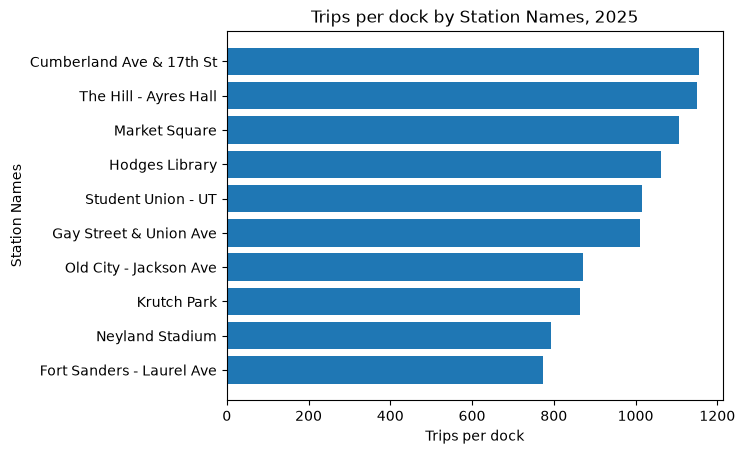

In [11]:
# TODO 9a: rebuild per_station with trips_per_dock, sorted ASCENDING;
#          show the 5 least- and 5 most-pressured stations
ended = merged[merged["no_end"] == False]

trips_per_station = (
    ended.groupby(["station_name","neighborhood", "docks"]).size().reset_index(name="trip_count") #need station names for horizontal bar chart below
)
trips_per_station["trips_per_dock"] = trips_per_station["trip_count"] / trips_per_station["docks"]

print(f"5 least-pressured:\n{trips_per_station.sort_values("trips_per_dock", ascending=True).head(5)}")
print(f"\n5 most-pressured:\n{trips_per_station.sort_values("trips_per_dock", ascending=True).tail(5)}")

# TODO 9b: horizontal bar chart of the 10 most-pressured stations, busiest at top
top = trips_per_station.sort_values("trips_per_dock", ascending=True).tail(10)
# print(top)
plt.barh(top["station_name"], top["trips_per_dock"]) # UT Campus - 4, Downtown - 3, Fort Sanders - 2, Old City - 1
plt.title("Trips per dock by Station Names, 2025")
plt.xlabel("Trips per dock")
plt.ylabel("Station Names")
# plt.gca().invert_yaxis()

**Q9c:** *Of the 10 stations with the most pressure (according to trips per dock) there are four stations in the UT Campus neighborhood and three stations in the Downtown neighborhood. Slack seems to be present especially at the Hill station where there is a lot of pressure, but not a lot of docks (e.g., The Hill with only 12 docks but over 1,000 trips per dock, and the Student Union and Hodges with only 24 docks but also over 1,000 trips per dock, etc.) and there is roughly a 1,000 trip difference between the top and bottom stations.*

*We charted the trips per dock rather than the raw trip counts to compare the pressure across stations with different numbers of docks and trips.*

---
## Part 10 — The Findings Memo (10 pts)

The one-pager for Friday's leadership meeting. In the markdown cell below,
write the memo using **exactly the five-part structure from class**:

1. **Bottom line first** — the answer to both questions, 1–2 sentences,
   no jargon.
2. **Evidence** — the two or three numbers that matter (with denominators),
   referencing your charts by name.
3. **Interpretation** — what you think explains the casual drop, *labeled
   as interpretation*.
4. **Limitations** — at least three honest ones (think: one year of data,
   observational timing, Week 3 judgment calls).
5. **Recommendation / next step** — what to do or what to *measure next*.

Target length: 150–250 words. The chronological lab diary ("First I loaded
the data...") caps at partial credit — the manager cares about the
destination, not your journey.


**Findings memo:** 

*Is ridership down?* Both rider types seem to have a natural progression, then decline throughout the year. However, ridership does seem to be down for casual riders starting in July. 

*Where should we add stations?* Of the 10 stations with the most pressure (according to trips per dock), there are four stations in the UT Campus neighborhood and three stations in the Downtown neighborhood.

*Evidence* For the ridership question, in comparison to the increase in member riders, the number of casual riders drops significantly (10.4% out of 31,279 (June) - 26,926 (July) total riders) from June to July 2025 (see Member vs. Casual Trips per Month, 2025 chart above). For the pressure question, slack seems to be present especially in the UT Campus neighborhood, where there is a lot of pressure, but not a lot of docks (e.g., The Hill with only 12 docks but about 1,156 trips per dock, and Hodges and the Student Union with only 24 docks have about 1,063 and 1,015 trips per dock respectively, etc.). Additionally, there is roughly a 1,000-trip difference between the top and bottom stations. Also, see the Trips per dock by Station Names, 2025 chart above.

*Interpretation* We can suspect that the decline in casual riders is from the price increase that was introduced in July 2025.

*Limitations* However, there are several limitations to consider. The decline in casual riders could be a consistent pattern, but we are unable to determine this without having other years to compare with 2025. We also flagged several trips that have no end station recorded, and those trips have been excluding from the analysis in answering these questions. This eliminates some data that may have led us to more genuine and accurate results. Additionally, the decision to exclude rides shorter than two minutes may have dropped 123 valid data points if those were genuine trips where riders took the bikes a very short distance.

*Recommendation/next step* Based on this new information, I suggest collecting more data in 2026 to compare with, expanding the number of docks in certain high-pressured neighborhoods, and creating an incentive to encourage casual riders to come back.

---
## Reflection + AI Disclosure (5 pts)

**R1.** Your manager asks point-blank: *"So should we reverse the price
increase?"* Write the 2–3 sentence answer you would actually give — honest
about what the data suggests and what it can't prove.

**R2.** **AI disclosure:** describe any use of
generative AI tools in this assignment, or state "No generative AI tools
were used." Example: *"I used a generative AI tool to debug my legend code.
All final charts and conclusions are my own."*


**R1:** *The data cannot prove that the price increase is exactly what caused the decline in casual riders. Instead of reversing the price increase, we should wait and make comparisons once we have some data from 2026.*

**R2:** *I used Google to fix the syntax of the two line graphs on the same graph. I was switching the indexing of the rows and columns inappropriately. All final charts and conclusions are my own.*

---
## Part 11 — Challenge (optional, +5 extra credit)

The memo answers *whether* casual riders left — the challenge asks *when
during the day* the two rider types differ.

**11a.** Compute trips by **hour of day** for each rider type
(`groupby(["hour", "rider_type"]).size().unstack()`).

**11b.** Plot both as lines on one labeled chart.

**11c.** In the markdown cell: describe the two daily rhythms you see
(commute peaks? afternoon leisure?), and state one way this chart
strengthens or complicates the "members = routine commuters, casuals =
leisure riders" interpretation from Part 4.


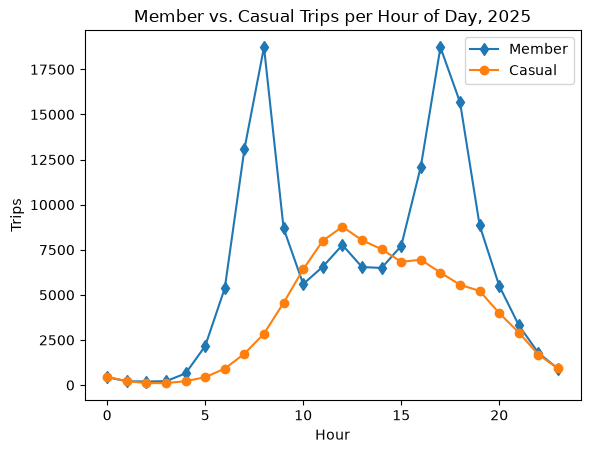

In [12]:
# TODO 11a: trips by hour of day per rider type
hourly = merged.groupby(["hour", "rider_type"]).size().unstack()

# TODO 11b: two-line chart of hourly rhythms
plt.plot(hourly.index, hourly["member"], label="Member", marker="d")
plt.plot(hourly.index, hourly["casual"], label="Casual", marker="o")
# plt.axvline(x=7, linestyle="--", color="gray") # July 1 price change
plt.title("Member vs. Casual Trips per Hour of Day, 2025")
plt.xlabel("Hour"); plt.ylabel("Trips"); plt.legend()

**Q11c:** *Both rhythms start and end the day with around the same number of trips though, but differences occur throughout the day. For member riders, there are two commute peaks (one in the morning around 7am and one in the afternoon around 5pm). For casual riders, there is a peak during the middle of the day. This strengthens the interpretation from Part 4 by visually and blatantly showing that members and casual riders do differ in this way throughout the day.*